In [180]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import RDLogger

RDLogger.DisableLog('rdApp.*')

import random

smis = [i.rstrip() for i in open("/home/andyt/DProjects/DMCTS/VINA_ChemTSv2/data/HCs/PCCP/hydros_minimal.smi", "r").readlines()]
mols = [Chem.MolFromSmiles(s) for s in smis]

# mols = random.sample(mols, 1000)

In [177]:
from rdkit.Chem.Scaffolds import MurckoScaffold

def get_murckoscaffold(m, makeGeneric=True, makeCyclicSkeleton=True, makeBajorath=True):
    PATT=Chem.MolFromSmarts("[$([D1]=[*])]")
    REPL=Chem.MolFromSmarts("[*]")
    
    Chem.RemoveStereochemistry(m)
    scaf = MurckoScaffold.GetScaffoldForMol(m)
    if makeBajorath:
        scaf = AllChem.DeleteSubstructs(scaf, PATT)
    if makeCyclicSkeleton:
        scaf = AllChem.ReplaceSubstructs(scaf,PATT,REPL,replaceAll=True)[0]                                         
    if makeGeneric:
        scaf = MurckoScaffold.MakeScaffoldGeneric(scaf)
        if makeCyclicSkeleton:
            scaf = MurckoScaffold.GetScaffoldForMol(scaf)
            
    return scaf

def cluster_by_murckoscaffold(mols, makeGeneric=True, makeCyclicSkeleton=True, makeBajorath=True):
    """ Bemis and Murkco define 'atomic frameworks' as rings and linkers with sidechains removed
        'graph frameworks' (makeGeneric) are atomic frameworks with all atoms set to carbon and all bonds single
        'cyclic skeletons' (makeCyclicSkeletons) remove substituents, leave only rings and linkers
        'bajorath' (makeBajorath) also removes substituents, without replacing with a placeholder
    """
    
    # Inchis are the best way to detect duplicate mols
    unique_inchis = {}
    for idx, m in enumerate(mols):
        scaf = get_murckoscaffold(m, makeGeneric=makeGeneric, makeCyclicSkeleton=makeCyclicSkeleton, makeBajorath=makeBajorath)
            
        inchi = Chem.MolToInchi(scaf)
        if inchi not in unique_inchis.keys():
            unique_inchis[inchi] = [idx]
        else:
            unique_inchis[inchi].append(idx)
    
    # clusters are numbered by the inchi key index
    cluster_labels = np.full(len(mols), -1)
    for count, (inchi, idxs) in enumerate(unique_inchis.items()):
        cluster_labels[idxs] = count
        
    return cluster_labels, list(unique_inchis.keys())

cluster_labels, inchis = cluster_by_murckoscaffold(mols)

In [178]:
pd.Series(cluster_labels).value_counts()

8       796
25      465
29      423
6       373
63      288
       ... 
559       1
560       1
561       1
565       1
1123      1
Name: count, Length: 1124, dtype: int64

493

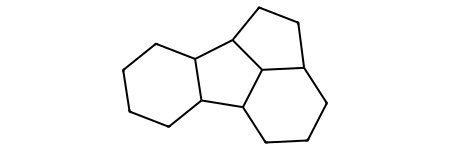

810

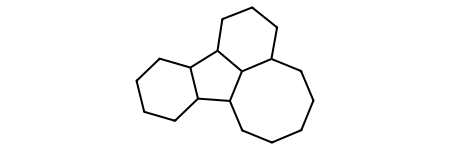

1

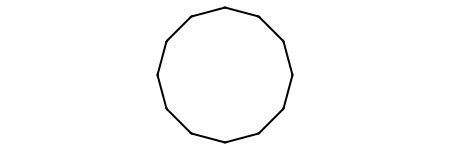

43

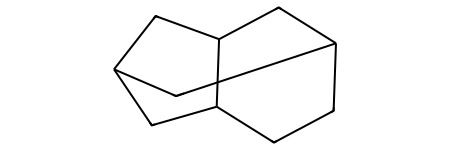

902

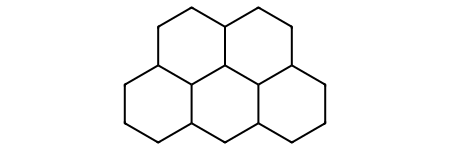

55

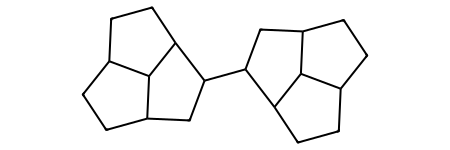

48

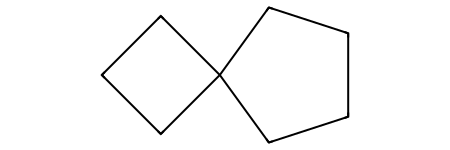

132

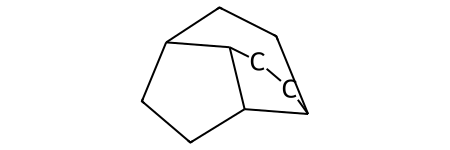

68

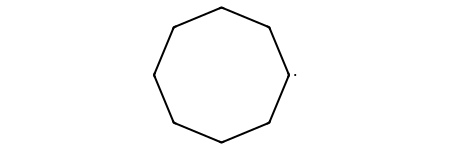

117

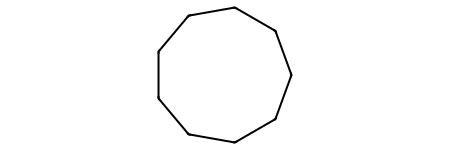

564

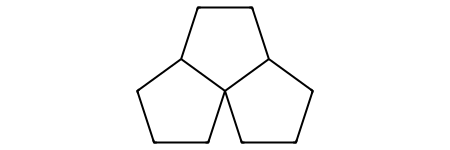

414

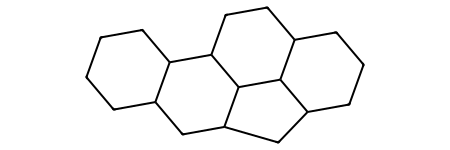

958

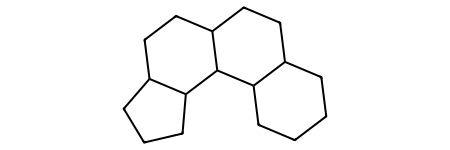

960

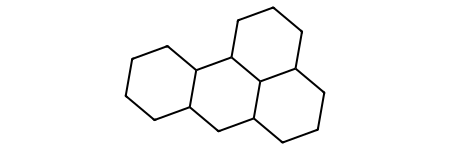

16

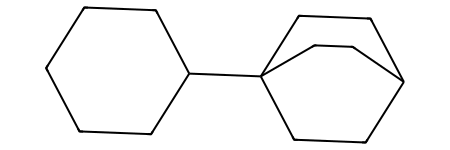

85

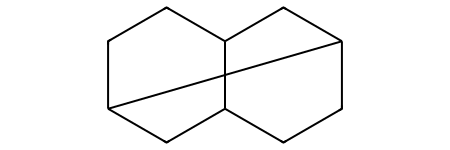

210

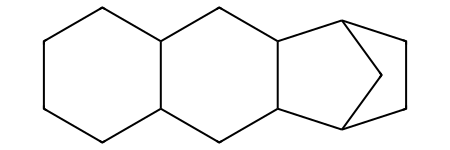

243

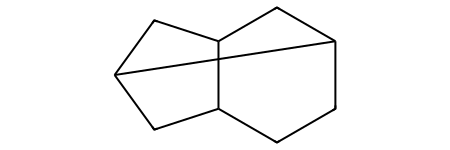

40

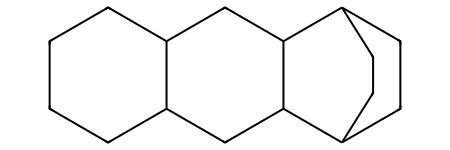

105

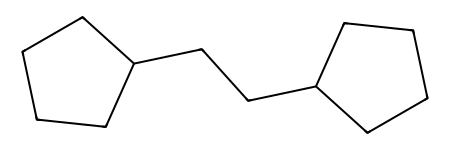

301

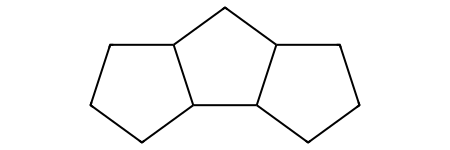

897

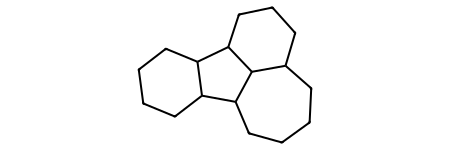

159

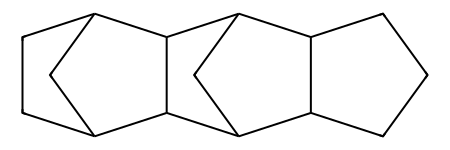

915

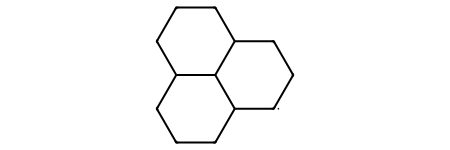

717

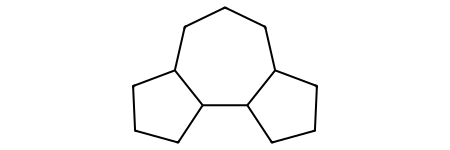

904

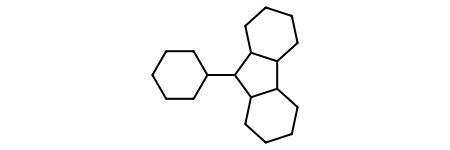

557

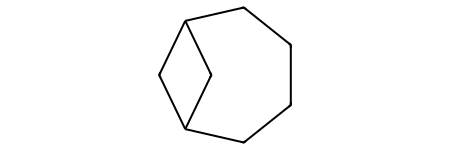

507

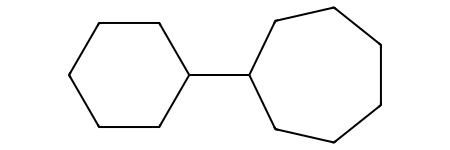

506

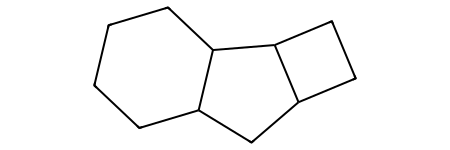

250

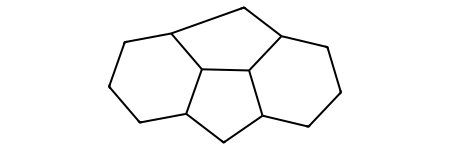

647

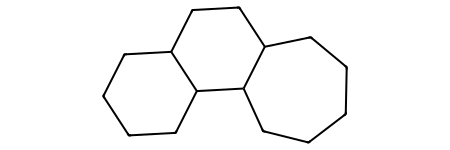

1058

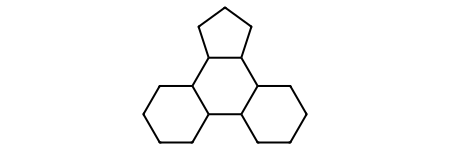

67

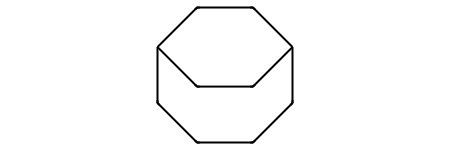

635

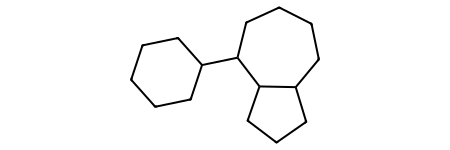

21

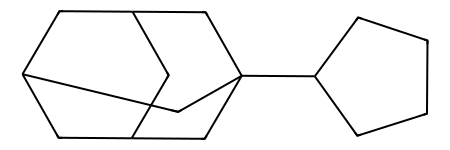

200

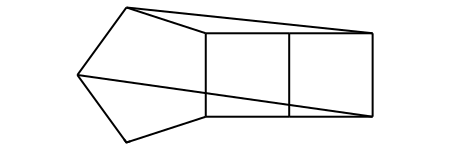

358

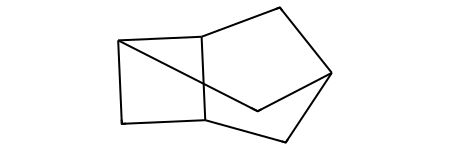

153

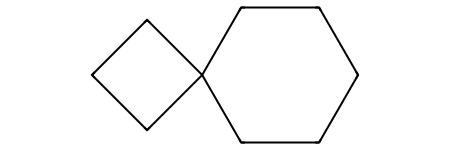

201

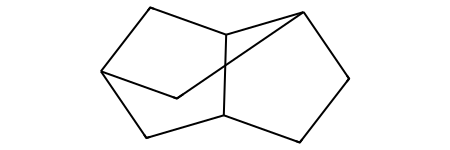

1032

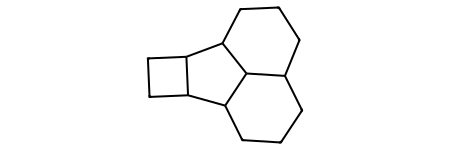

239

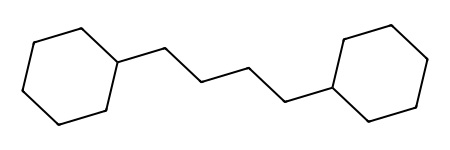

182

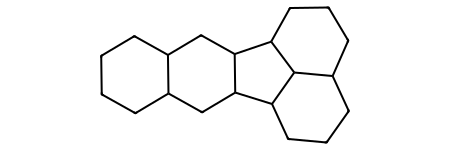

0

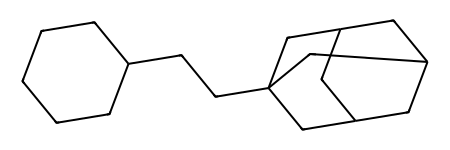

547

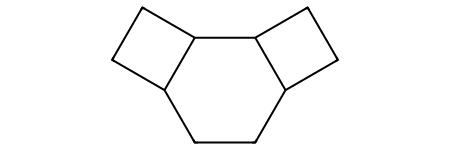

863

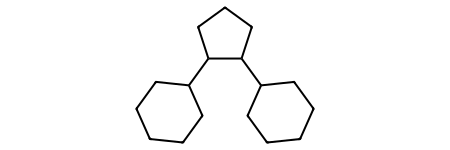

896

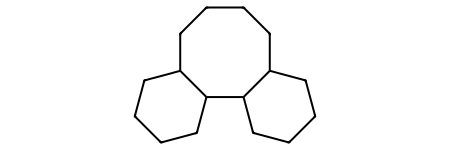

785

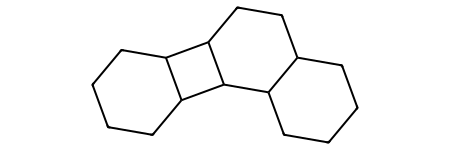

886

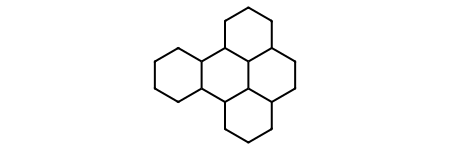

700

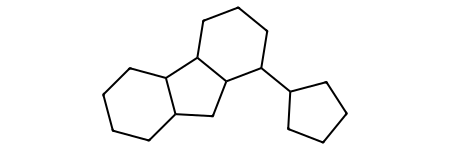

391

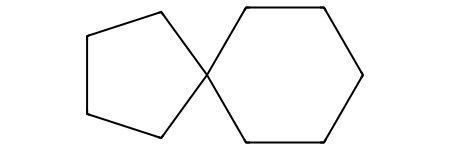

128

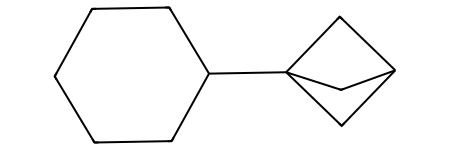

54

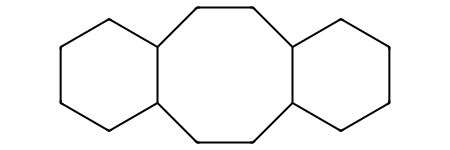

90

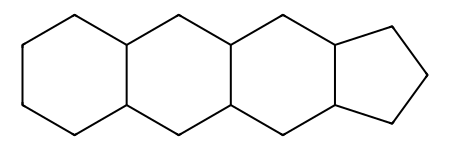

594

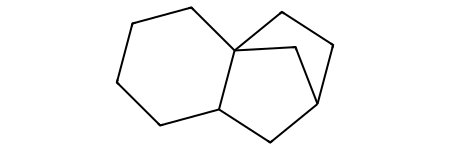

446

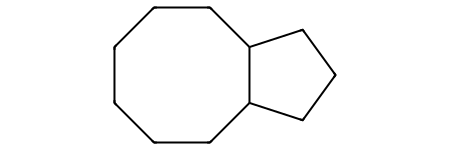

543

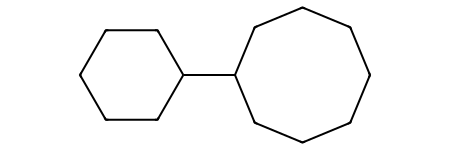

269

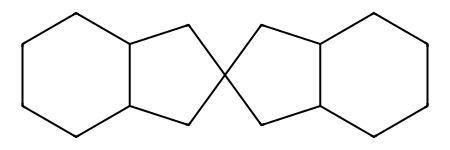

1033

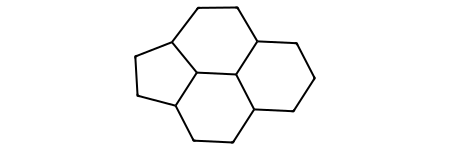

191

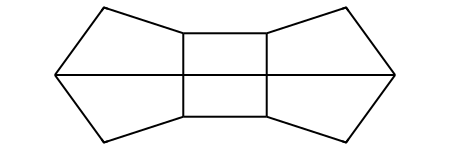

237

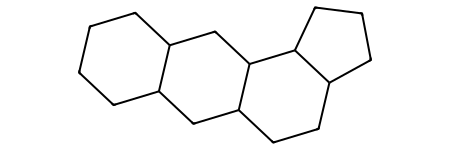

1055

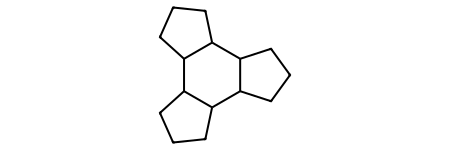

197

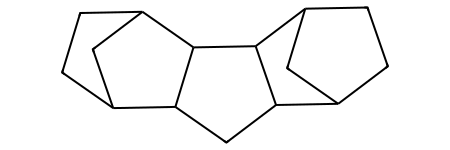

199

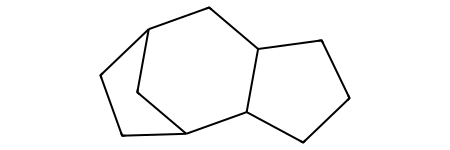

205

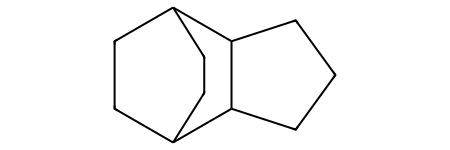

80

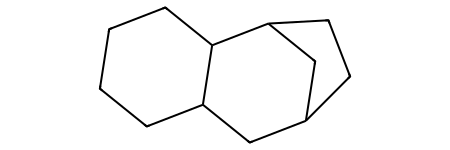

138

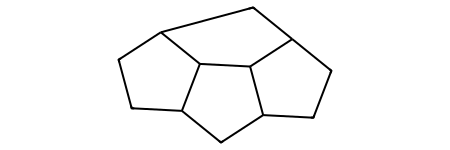

457

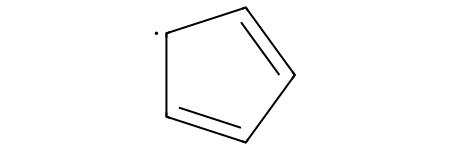

922

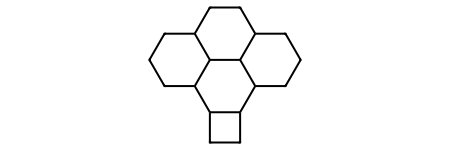

945

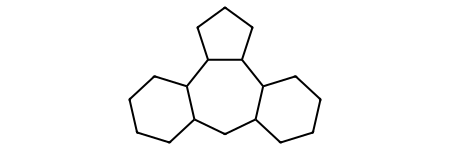

311

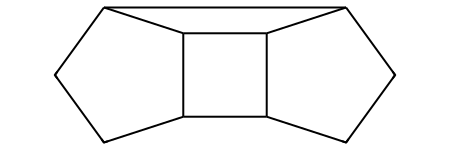

323

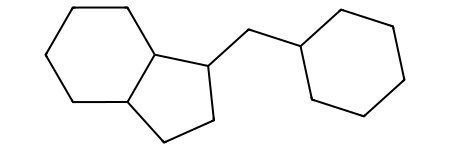

134

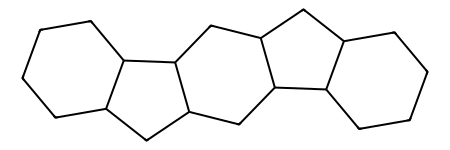

146

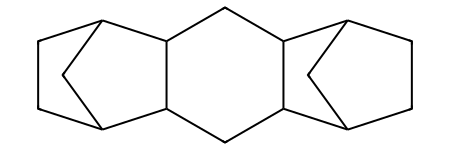

310

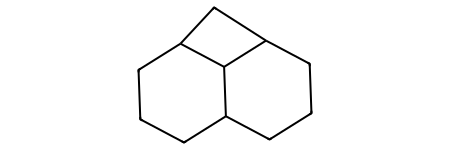

400

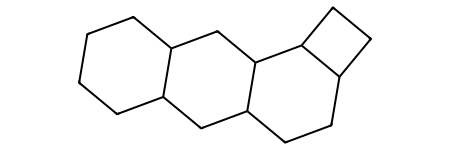

328

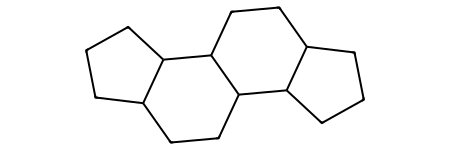

917

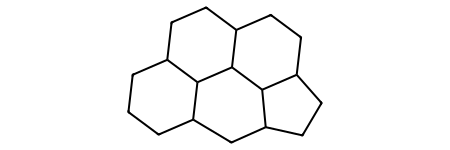

101

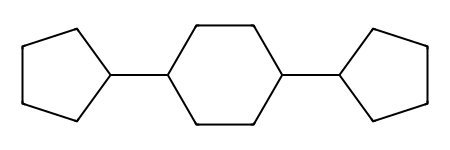

165

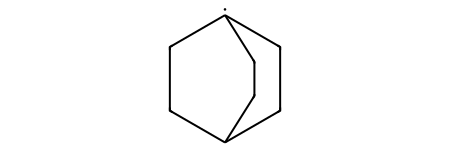

217

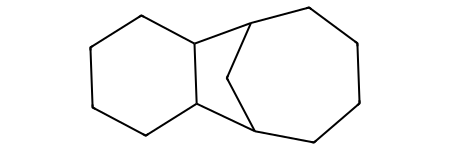

764

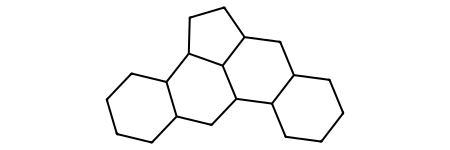

726

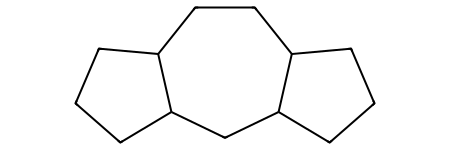

407

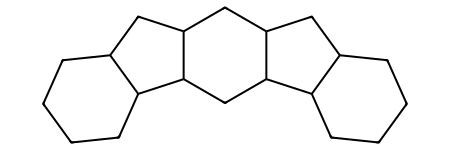

740

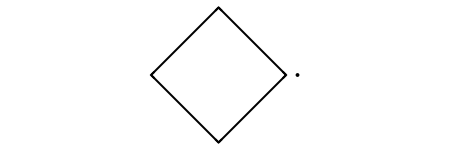

326

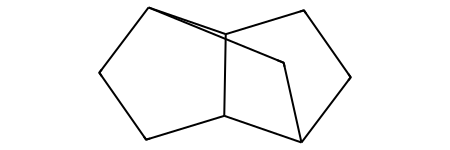

214

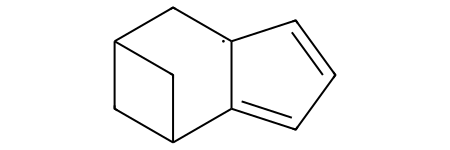

396

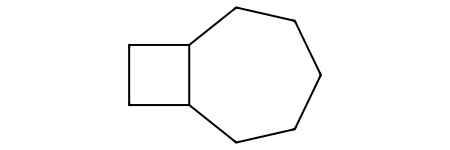

675

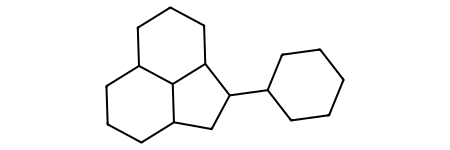

662

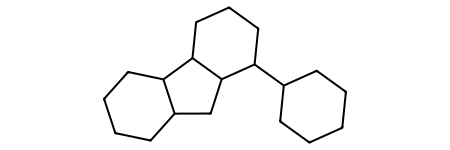

660

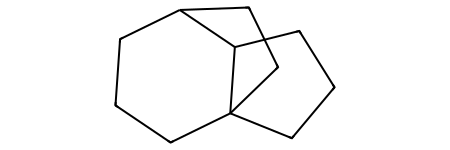

912

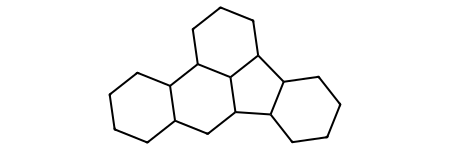

608

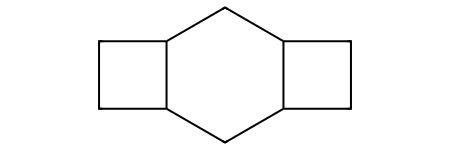

644

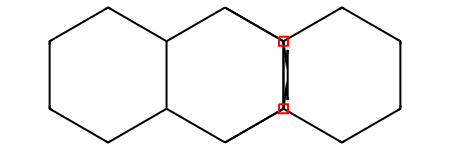

624

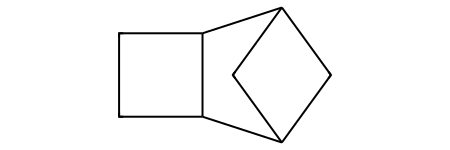

611

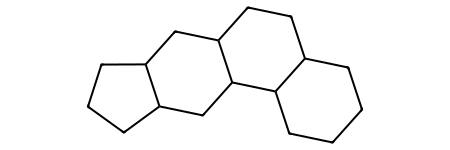

905

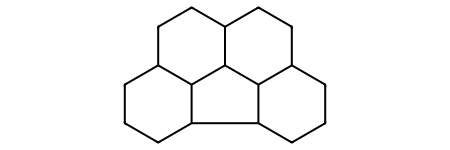

942

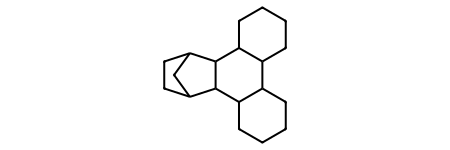

253

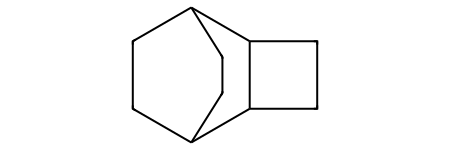

580

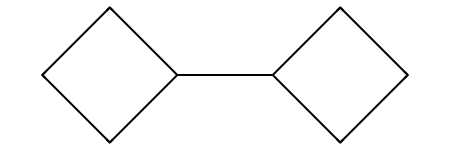

866

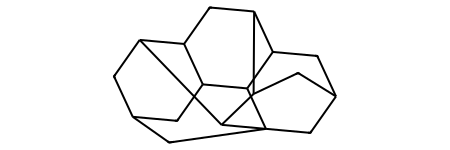

In [188]:
import pandas as pd

# Most common generic scaffolds
for i in pd.Series(cluster_labels).value_counts().iloc[100:200].index:
    display(i, Chem.MolFromInchi(inchis[i]))

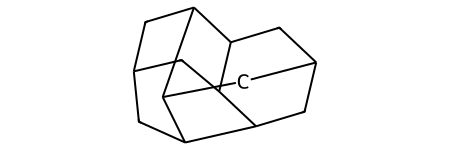

In [184]:
# search for scaffold
query_smi = "C1C2CC3C4C1C5CC(C4)CC3C5C2"
query_mol = Chem.MolFromSmiles(query_smi)
query_scaf = get_murckoscaffold(query_mol)

display(query_scaf)